We are attempting to obtain a parametrized two-qubit $CZ_{\phi}$ gate (same as the $CPHASE$ gate). 

To start off we run/import some code that is used both for single-angle optimizations and multi-angle optimizations.

In [1]:
import torch 
from decimal import Decimal
from schsolve import neural_trainer, schsolver 
import schsolve
import torchdiffeq as tdf 
import cst_n_fn as cfn 
import matplotlib.pyplot as plt 
import const_cczphi as cczphi 
import numpy as np 
import pytorch_warmup as warmup 
from const_cczphi import reduce_r_dim_3q_vector, correction_1q, correction_1q_param

device = "cpu"

print(device)
    
# **** training function below ****
# Note that this has to be coded separately for each use case 
        
def trainer(neural_model, nn_solver_1, nn_solver_2, input_tensor, scheduler, epoch, init_matrix, multiplier = 2.0, print_ = True):
    
    #trial_1q_rot.train()
    neural_model.train()
    nn_solver_1.zero_grad()
    nn_solver_2.zero_grad()
    #nn_solver_3.zero_grad()
    nn_time_output = (neural_model(input_tensor).select(1,0))
    
    pred_outputs_detuning = nn_time_output*(neural_model.range_detuning[1]\
         - neural_model.range_detuning[0]) + neural_model.range_detuning[0]
        
    cczphi.instance.hamiltonian.rabi_tensored["pulse 0"] \
    = cczphi.instance.hamiltonian.rabi_tensored["pulse 1"] \
    = cczphi.instance.hamiltonian.rabi_tensored["pulse 2"]\
    = cfn.const_then_zero_tensor(cfn.rabi, neural_model.gatetime_prediction)

    cczphi.instance.hamiltonian.det_tensored["pulse 0"] \
    = cczphi.instance.hamiltonian.det_tensored["pulse 1"] \
    = cczphi.instance.hamiltonian.det_tensored["pulse 2"] \
    = cczphi.list_to_fn_tensor_var_gatetime(pred_outputs_detuning,\
         neural_model.gatetime_prediction, cczphi.time_steps)    
    
    time_arr_ = torch.linspace(0, 1.0, 3, device = device)*neural_model.gatetime_prediction.max()
    
    # * code below evolves the Hamiltonian with time-dependent controls and computes the state in the subspace of 0s and 1s

    sol_intrm = reduce_r_dim_3q_vector(tdf.odeint(cczphi.instance,\
                                init_matrix, time_arr_, 
                                method = 'dopri5', rtol = 5e-5, atol = 5e-5)[-1], angle_batch = cczphi.angle_batch)

    solution = correction_1q_param(sol_intrm, angle_guess, angle_batch = cczphi.angle_batch) 
    
    #var_rotation_1q = trial_1q_rot().reshape(cczphi.angle_batch, 8, 8)
    #print(sol_intrm.shape)
    #print(torch.angle(sol_intrm[:, 1, 1]))
    #solution = torch.bmm(var_rotation_1q, sol_intrm)

    #solution = torch.exp()
    infidelity_term = cfn.unitary_infidelity_array(solution, \
        cfn.cczp_gate_stack_zzz(input_tensor/neural_model.scale_factor +\
             neural_model.offset), nqbits = 3)

    time_term = multiplier*torch.mean(neural_model.gatetime_prediction)
    
    dict_ = {"time term": time_term.item(), "infidelity term": infidelity_term.item(),
                "gatetime mean.": torch.mean(neural_model.gatetime_prediction)}
    
    loss_instance = infidelity_term + time_term 
    
    neural_model.debug_gradient_time.retain_grad()
    nn_time_output.retain_grad()
    loss_instance.backward()
    
    #nn_solver_3.step()
    nn_solver_2.step()
    nn_solver_1.step()
    
    if scheduler[0] == True:
        scheduler[2].step()
        scheduler[1].step()
    
    if epoch%5 == 0 and print_ == True:  
        
        #print(neural_model.gatetime_prediction.max()*cfn.rabi)
        
        print("Epoch {}: Loss = {:.2E}".format(epoch, Decimal(loss_instance.cpu().detach().numpy().item())))
        #print(trial_1q_rot.f)
        print(dict_)
        print(torch.angle(sol_intrm[:, 1, 1]))
        #print('gradient time!')
        #print(sum(neural_model.debug_gradient_time.grad))
        #print('gradient control!')
    
    return solution.cpu().detach().numpy(), loss_instance.item(), dict_

def scale_and_offset(angle_arr, network):
    
    # * This function scales the angle by some factor (useful for small angles)
    # * And also subtracts an offset s.t. the mean = 0 

    a = (angle_arr - network.offset)*network.scale_factor 

    return a 

/opt/homebrew/Caskroom/miniconda/base/envs/baseClone/lib/python3.11/site-packages/qutip/__init__.py:65: UserWarning: The new version of Cython, (>= 3.0.0) is not supported.
  warnings.warn(


cpu


Note: the code cell right below is to to demonstrate (and potentially utilize) file handling i.e. loading a pre-trained NN. You can comment out the lines if you just want to train a randomly initialized NN. The current net being loaded is the 'final' i.e. converged net for the range $[0.5\pi, \pi]$. 

In [8]:
filename = "data/final_models/5e-5pi_to_0.05pi"
filename = "data/3qbit/pi10"

load_dict = torch.load(filename)

composite_network = load_dict["network"].to(device)

composite_network._aux_tensor = composite_network._aux_tensor.to(device)
nn_solver_1 = (load_dict["solver"])[0]
nn_solver_2 = (load_dict["solver"])[1]
angle_guess = load_dict["solver"][2]
#trial_1q_rot = load_dict["solver"][1]

desired_angle = load_dict["angle"].to(device)


In [ ]:
# See cphase code on how to initialize network in such a way it reproduces a known result at pi 

tensor(13.4685, grad_fn=<MulBackward0>)


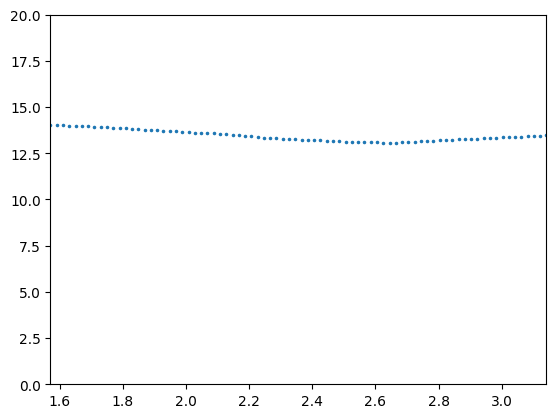

In [40]:
# NOTE: Comment out the composite_network lines below if you want to train a pre-loaded NN 
# that you loaded above 

composite_network = cczphi.neural_trainer_time_optimal_cz(nl1 = 4, nu1 = 45, nl2 = 16, \
   nu2 = 300, beta_control = 2.45, time_bounds = [4.5/cfn.rabi, 20.0/cfn.rabi],\
      range_detuning = [-3.0*cfn.rabi, 3.0*cfn.rabi], beta_time = 1.52, mode = 'sig',\
         scale_factor = 1e0)

composite_network.angle_range = [0.5*torch.pi, 1.0*torch.pi] 
composite_network.offset = np.mean(composite_network.angle_range)
#composite_network.scale_factor = 1e0

# scale factor is 1 for large angles 

plt_range = composite_network.angle_range
plt_range = np.array(plt_range) #*composite_network.scale_factor 

angle_list = torch.linspace(plt_range[0], plt_range[1], 80).reshape(80, 1)
#composite_network.offset = torch.mean(angle_list).item()
# ! need to add a scale factor here! 
composite_network(scale_and_offset(angle_list, composite_network)) 

plt.scatter(angle_list.detach().numpy(), composite_network.gatetime_prediction.detach().numpy()*cfn.rabi, s=2.4)

plt.xlim(plt_range[0], plt_range[1])
plt.ylim(0, 20.0)
print((composite_network.gatetime_prediction.T[0][-1]*cfn.rabi))
#print((sorted_)*2*4*torch.pi)

In [ ]:
print(np.array(composite_network.time_bounds)*cfn.rabi)

# Single angle optimization 

Run the code below to find the time-optimal $CPHASE$ gate for a given angle (as opposed to multiple angles which we will look at later). This is a good way to get started. 

In [42]:
# only optimizing for a single angle 

init_matrix = cczphi.init_matrix
custom_range = [0.5*torch.pi, 1*torch.pi]

desired_angle = torch.tensor([[1*torch.pi]])
angle_input = scale_and_offset(desired_angle, composite_network)

print("Optimization for the angle: ")
print((desired_angle/torch.pi)/composite_network.scale_factor)

Optimization for the angle: 
tensor([[1.]])


In [ ]:
print(custom_range)

tensor([[0.5309]], grad_fn=<AddBackward0>)
tensor([ 1.9433,  1.9395,  1.9343,  1.9290,  1.9218,  1.9132,  1.9038,  1.8902,
         1.8751,  1.8586,  1.8417,  1.8242,  1.8061,  1.7876,  1.7690,  1.7501,
         1.7314,  1.7131,  1.6948,  1.6772,  1.6600,  1.6435,  1.6283,  1.6183,
         1.6242,  1.6392,  1.6633,  1.6996,  1.7440,  1.7897,  1.8346,  1.8791,
         1.9224,  1.9656,  2.0077,  2.0484,  2.0879,  2.1255,  2.1615,  2.1959,
         2.2290,  2.2598,  2.2878,  2.3113,  2.3300,  2.3355,  2.3280,  2.3116,
         2.2819,  2.2344,  2.1691,  2.0807,  1.9740,  1.8523,  1.7171,  1.5686,
         1.4053,  1.2281,  1.0536,  0.8749,  0.7124,  0.5841,  0.4735,  0.3900,
         0.3274,  0.2837,  0.2500,  0.2168,  0.1843,  0.1544,  0.1273,  0.0970,
         0.0671,  0.0399,  0.0152, -0.0089, -0.0349, -0.0611, -0.0870, -0.1133,
        -0.1406, -0.1680, -0.1948, -0.2216, -0.2465, -0.2705, -0.2938, -0.3159,
        -0.3385, -0.3611, -0.3844, -0.4074, -0.4296, -0.4504, -0.4691, -0.486

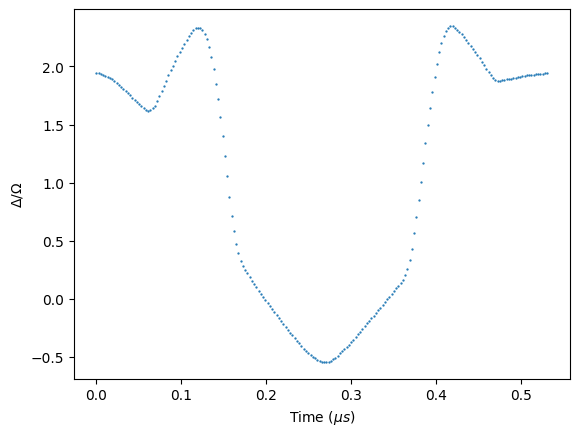

In [19]:
# We plot the initial controls of the randomly initialized network just to make sure 
# that the controls are not close to 0 -- as this can lead to convergence issues. 
# if the controls are close to 0 for your use case, you can play around with the value of beta
# this is a rescaling factor for the initial (random) values of the neural network parameters.
#desired_angle = torch.tensor([[1*torch.pi]], device = device) #  for the angle pi i.e. CZ gate 
# print(composite_network.range_detuning)

pred_outputs_detuning = \
    (composite_network(angle_input).select(1,0))*\
    (composite_network.range_detuning[1] - composite_network.range_detuning[0])\
         + composite_network.range_detuning[0]
         
print(composite_network.gatetime_prediction)
print(pred_outputs_detuning/(cfn.rabi))
#print(pred_outputs_rabi)
# mb gatetime_prediction.detach().clone() instead of calling directly? 
plt.xlabel(r'Time ($\mu s$)')
plt.ylabel(r'$\Delta/\Omega$ ') # * phi represents the phase 
time_arr = np.linspace(0, composite_network.gatetime_prediction.item(), cczphi.time_steps)
rabi_arr = []

plt.scatter(time_arr, pred_outputs_detuning.detach().numpy()/cfn.rabi, s = 0.4)
#plt.ylim(-2,2)
plt.show()

#plt.xlabel(r'Time ($\mu s$)')
#plt.ylabel(r'$\Omega/\Omega_{max}$ ')
#plt.scatter(time_arr, pred_outputs_rabi.detach().numpy()/cfn.rabi, s = 0.4)

# Multi angle optimization 

In [ ]:
%matplotlib widget
# ! Add code for the 3D plot with variable gatetimes  

In [ ]:
print(composite_network.ansatz_control(composite_network.ansatz_time(desired_angle)))

In [ ]:
print(nn_solver_1)
#print(nn_solver_2)
print(cczphi.time_steps)

In [42]:
# Build param_group where each group consists of a single parameter.
# `param_group_names` is created so we can keep track of which param_group
# corresponds to which parameter.

angle_guess = torch.nn.Parameter(torch.pi*torch.rand(1, dtype=torch.float64))  # Initial guess for theta
print("angle guess = " + str(angle_guess))

nn_solver_1 = torch.optim.Adam(composite_network.ansatz_time.parameters(),\
     lr = 1e-5, eps = 1e-5, amsgrad = True)#, eps = 1e-4)

#nn_solver_1 = torch.optim.SGD(composite_network.ansatz_time.parameters(), \
#    lr=1e-4, momentum=0.9, weight_decay=0e-4, nesterov=True)

param_groups = []
param_group_names = []
for name, parameter in composite_network.ansatz_control.named_parameters():
    
    param_groups.append({'params': [parameter], 'lr': 1e-4})
    param_group_names.append(name)
    
param_groups.append({'params' : [angle_guess], 'lr': 1e-3})
param_group_names.append('corr. Rz rotation')
nn_solver_2 = torch.optim.Adam(param_groups, lr=1e-4, amsgrad = True, eps = 1e-5) 

#nn_solver_2 = torch.optim.SGD(param_groups, \
#    lr= 5e-4, momentum=0.9, weight_decay=0e-4, nesterov=True) # differentiable = True)



angle guess = Parameter containing:
tensor([2.4202], dtype=torch.float64, requires_grad=True)


In [16]:
"""for g in nn_solver_1.param_groups:
    g['lr'] = 5e-5
for g in nn_solver_2.param_groups:
    g['lr'] = 5e-5
"""
#for g in nn_solver_.param_groups:
#    g['lr'] = 5e-3

#for name, param_group in zip(param_group_names, nn_solver_.param_groups):

#    print(name, param_group)
#for i in nn_solver_1.param_groups:
#    i['lr'] = 1e-4
    #i['momentum'] = 0.5

for i in range(0, len(nn_solver_2.param_groups)):
    nn_solver_2.param_groups[i]['lr'] = 1e-5

nn_solver_2.param_groups[-1]['lr'] = 1e-4

In [15]:
print(nn_solver_1)
print(nn_solver_2)

In [4]:
lr_scheduler_1 = torch.optim.lr_scheduler.CosineAnnealingLR(nn_solver_1, T_max=1e3)
#warmup_scheduler_1 = warmup.UntunedLinearWarmup(nn_solver_1)

lr_scheduler_2 = torch.optim.lr_scheduler.CosineAnnealingLR(nn_solver_2, T_max=1e3)
#warmup_scheduler_2 = warmup.UntunedLinearWarmup(nn_solver_2)

#scheduler = [lr_scheduler_1, warmup_scheduler_1, lr_scheduler_2, warmup_scheduler_2]
lr_scheduler_1 = schsolve.WarmupScheduler(nn_solver_1, 30, 1e-8, 6e-5)
lr_scheduler_2 = schsolve.WarmupScheduler(nn_solver_2, 30, 1e-5, 1e-4)

scheduler = [False, lr_scheduler_1, lr_scheduler_2]

In [5]:
#trial_1q_rot = cczphi.arbitrary_z_global()#cczphi.arbitrary_1q_global_3()
init_matrix = cczphi.init_matrix 
composite_network.offset = sum(composite_network.angle_range)/2
print(composite_network.angle_range)

[1.5707963267948966, 3.141592653589793]


In [22]:
desired_angle = torch.tensor([[0.8*torch.pi]], device = device)
#composite_network.offset = 0.0
angle_input = scale_and_offset(desired_angle, composite_network)
print(angle_input*torch.pi)
#composite_network.angle_range = [5e-5*torch.pi, 0.05*torch.pi] 
custom_range = np.array(composite_network.angle_range)
#composite_network(angle_list)
#composite_network.offset = np.mean(custom_range)
#composite_network.time_bounds = [8/cfn.rabi, 18.5/cfn.rabi]

composite_network.scale_factor = 1e0
# ! currently: using a larger scale factor 
composite_network.range_detuning = [-3.0*cfn.rabi, 3.0*cfn.rabi]

# ! multiplier is currently 1e-2 
for epoch_ in range(int(1e5)):

    #if epoch_ %2.5e1 == 0:

    #    desired_angle = \
    #        ((torch.rand(cczphi.angle_batch, 1, device=device)* \
    #        (custom_range[1] - custom_range[0]) + \
    #        custom_range[0]))
    #    angle_input = scale_and_offset(desired_angle, composite_network)

    soln, loss, dict_ = trainer(composite_network, nn_solver_1, nn_solver_2,\
        angle_input, scheduler, epoch = epoch_, multiplier = 1e-4, init_matrix = init_matrix, print_ = True) # for the composite NN 
    # !try multiplier to e-2
    if epoch_ % 1e2 == 0:
        print((loss, dict_, angle_guess))
    
# can i increase the number of samples taken later? 
# torch.angle: 1.7597
# parameter: -1.2526

tensor([[0.4935]])
Epoch 0: Loss = 5.98E-1
{'time term': 5.042097473051399e-05, 'infidelity term': 0.5979090332984924, 'gatetime mean.': tensor(0.5042, grad_fn=<MeanBackward0>)}
tensor([2.0468], grad_fn=<AngleBackward0>)
(0.5979594588279724, {'time term': 5.042097473051399e-05, 'infidelity term': 0.5979090332984924, 'gatetime mean.': tensor(0.5042, grad_fn=<MeanBackward0>)}, Parameter containing:
tensor([1.6928], dtype=torch.float64, requires_grad=True))
Epoch 5: Loss = 5.36E-1
{'time term': 5.02067559864372e-05, 'infidelity term': 0.5359562039375305, 'gatetime mean.': tensor(0.5021, grad_fn=<MeanBackward0>)}
tensor([1.9362], grad_fn=<AngleBackward0>)
Epoch 10: Loss = 4.58E-1
{'time term': 4.991660171071999e-05, 'infidelity term': 0.4581131339073181, 'gatetime mean.': tensor(0.4992, grad_fn=<MeanBackward0>)}
tensor([1.4978], grad_fn=<AngleBackward0>)
Epoch 15: Loss = 4.29E-1
{'time term': 4.97088476549834e-05, 'infidelity term': 0.4293673634529114, 'gatetime mean.': tensor(0.4971, grad

In [8]:
print(nn_solver_1)

Adam (
Parameter Group 0
    amsgrad: True
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 0.0001
    foreach: None
    fused: None
    initial_lr: 0.0001
    lr: 0.0001
    maximize: False
    weight_decay: 0
)


In [ ]:
print(custom_range)
print([5e-5*torch.pi, 0.005*torch.pi])

tensor([[0.4135, 0.4135, 0.4135, 0.4135, 0.4135, 0.4135, 0.4135, 0.4135, 0.4135,
         0.4135, 0.4135, 0.4135, 0.4135, 0.4135, 0.4135, 0.4135, 0.4135, 0.4135,
         0.4135, 0.4135, 0.4135, 0.4135, 0.4136, 0.4136, 0.4136, 0.4136, 0.4136,
         0.4136, 0.4136, 0.4136, 0.4136, 0.4136, 0.4136, 0.4136, 0.4136, 0.4136,
         0.4136, 0.4136, 0.4136, 0.4136, 0.4136, 0.4136, 0.4136, 0.4136, 0.4136,
         0.4136, 0.4136, 0.4136, 0.4136, 0.4136, 0.4136, 0.4136, 0.4136, 0.4136,
         0.4136, 0.4136, 0.4136, 0.4136, 0.4136, 0.4136, 0.4136, 0.4137, 0.4137,
         0.4137, 0.4137, 0.4137, 0.4137, 0.4137, 0.4137, 0.4137, 0.4137, 0.4137,
         0.4137, 0.4137, 0.4138, 0.4138, 0.4138, 0.4138, 0.4138, 0.4138]],
       grad_fn=<PermuteBackward0>)


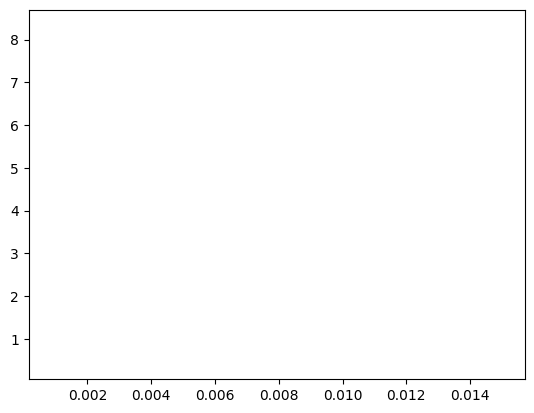

In [88]:

#composite_network.ansatz_time = model 
# ? try reducing number of neurons 
#composite_network = cczphi.neural_trainer_time_optimal_cz(nl1 = 2, nu1 = 45, nl2 = 9, \
#    nu2 = 300, beta_control = 1.95, time_bounds = [5.5/cfn.rabi, 8.5/cfn.rabi], beta_time = 2.05)

#print(composite_network.gatetime_prediction)
plt_range = [5e-5*torch.pi, 0.005*torch.pi] 
angle_list = torch.linspace(plt_range[0], plt_range[1], 80).reshape(80, 1)

composite_network(angle_list) 
#composite_network(angle_list) 
#sorted_, _ = torch.sort(composite_network.gatetime_prediction, dim = 0)
#sorted_angle, _ = torch.sort(desired_angle, dim = 0)
plt.scatter(angle_list.detach().numpy(), composite_network.gatetime_prediction.detach().numpy()*cfn.rabi, s=2.4)
#plt.scatter(sorted_angle.detach().numpy(), sorted_.detach().numpy()*cfn.rabi, s=2.4)

x_arr = [0.05847605202762446, 0.09368133926144129, 0.02553674111901877, 0.12202160567522635, 0.16003611609405566, 0.24413213708770543, 0.3608541207127307, 0.4828156660963421, 0.5925537648106403, 0.6828254544699208, 0.8650083393362422, 0.9700092097167208, 1.0899796914958313, 1.2832984815261785, 1.3989175729994532, 1.5187260724968614, 1.6395984551609901, 1.7358666172693598, 1.8735801205673441, 1.9866724565710312, 2.09323202133587, 2.183381753405148, 2.3227001711518453, 2.453807876555414, 2.5711061215651685, 2.6829292712776533, 2.823922793003788, 2.9481701092904693, 3.038817560173, 3.146991745070998]

y_arr = [3.5941027524177587, 3.938737981277658, 3.0640654170130324, 4.168456623425607, 4.45059841976562, 4.910650536663227, 5.254585868573394, 5.596251576465882, 5.853283139036311, 5.99639367713345, 6.283705918720844, 6.414477894295825, 6.538290393011855, 6.743657312659085, 6.849114251113775, 6.935138852908203, 7.030197134928828, 7.0991086362566005, 7.186596171618144, 7.233695935987047, 7.297650376324034, 7.3382753032677375, 7.397785785092296, 7.440760914421173, 7.482294746164857, 7.524834368602767, 7.536685144221717, 7.583423794921136, 7.583418199201171, 7.62755164256274]
plt.scatter(x_arr,y_arr, s = 2.4)
# 6.41
plt.xlim(plt_range[0], plt_range[1])
plt.ylim(0.05, 8.7)

print(composite_network.gatetime_prediction.T)
#print((sorted_)*2*4*torch.pi)

In [ ]:
print(nn_solver_1)

In [ ]:
# Code to plot the time 
angle_list = torch.linspace(0, 0.1*np.pi, cczphi.angle_batch).reshape(cczphi.angle_batch, 1)
composite_network(angle_list)
print(composite_network.gatetime_prediction)
plt.scatter(angle_list.detach().numpy(), composite_network.gatetime_prediction.detach().numpy()*(np.pi))


In [ ]:
# code to plot variance in fidelity 
import schsolve

angle_list = torch.linspace(0.0, 1*np.pi, cczphi.angle_batch).reshape(cczphi.angle_batch, 1)

instance = schsolve.schsolver(cczphi.system, 1, mode = "single").to(device)

for i in angle_list: 

    i = i.reshape(1,1)
    #print(cfn.czp_gate_stack(i).shape)
    #print(composite_network(i.reshape(1,1)).shape)
    pred_outputs_detuning = (composite_network(i).\
        select(1,0))*(composite_network.range_detuning[1] - composite_network.range_detuning[0]) + composite_network.range_detuning[0]
    print(pred_outputs_detuning.shape)
    instance.hamiltonian.rabi_tensored["pulse 0"] = instance.hamiltonian.rabi_tensored["pulse 1"]\
    = cfn.const_then_zero_tensor(cfn.rabi, composite_network.gatetime_prediction)
    
    instance.hamiltonian.det_tensored["pulse 0"] = instance.hamiltonian.det_tensored["pulse 1"]\
        = cczphi.list_to_fn_tensor_var_gatetime(pred_outputs_detuning, composite_network.gatetime_prediction, cczphi.time_steps)
    
    # gatetime should now be max of cczphi
    
    time_arr_ = torch.linspace(0, 1.0, cczphi.time_steps, device = device)*composite_network.gatetime_prediction.max()
    #print(time_arr_.requires_grad)

    sol_intrm = reduce_r_dim_2q_vector(tdf.odeint(instance,\
                                torch.eye(9).reshape(1,9,9), time_arr_, 
                                method = 'rk4')[-1], angle_batch = 1)
    #'rk4'
    #print(sol_intrm.is_cuda)
    solution = correction_1q(sol_intrm, angle_batch = 1) 
        #print(cfn.czp_gate_stack(i).shape)
    fidelity = (cfn.unitary_infidelity_array(cfn.czp_gate_stack(i), solution, nqbits = 2))
    print(fidelity)

#    cfn.unitary_infidelity_array(cfn.czp_gate_stack(i).reshape(1,1), composite_network(i).reshape(1,1))

# Code to save the optimization results
Allows us to save and load results later e.g. to further optimize a partially converged network or to use some network as the initial guess for a different optimization problem. 

In [21]:

#soln = torch.tensor(soln)
filename = "data/3qbit/pi12"
dict_ = cfn._optim_to_dict(composite_network, \
    'n/a', desired_angle, 'n/a', [nn_solver_1, nn_solver_2, angle_guess], loss_val = 'n/a')

torch.save(dict_, filename)

# Sequential partial training of random networks
Trains randomly initialized networks for 50 epochs and saves the results. 

In [ ]:
n_networks = 500
n_iterations = 11

custom_domain = [0.5*torch.pi, 1.0*torch.pi] 
desired_angle = torch.tensor([[1*torch.pi]])

for net_id in range(n_networks):
  
  init_matrix = cczphi.init_matrix.detach().clone() 
  t_pi_pred = torch.zeros(1)

  while t_pi_pred.item() > 11.05 or t_pi_pred.item() < 10.70:

    composite_network = cczphi.neural_trainer_time_optimal_cz(nl1 = 3, nu1 = 45, nl2 = 14, \
    nu2 = 300, beta_control = 1.95, time_bounds = [4.05/cfn.rabi, 14.0/cfn.rabi], beta_time = 2.05)
    tb = composite_network.time_bounds 
    composite_network(torch.tensor([[torch.pi]]))
    t_pi_pred = composite_network.gatetime_prediction

  # ! add angle_guess here as well! 
  
  nn_solver_1 = torch.optim.Adam(composite_network.ansatz_time.parameters(), lr=1e-4, \
    eps=1e-5, amsgrad = True) 
  nn_solver_2 = torch.optim.Adam(composite_network.ansatz_control.parameters(), lr=1e-4,\
    eps=1e-5, amsgrad = True)

  for epoch_ in range(n_iterations):

    #if epoch_ %1e1 == 0:
    #desired_angle = torch.rand(cczphi.angle_batch, 1, device=device) * \
    #            (custom_domain[1] - custom_domain[0]) + \
    #            custom_domain[0]

  
    soln, loss, dict_ = trainer(composite_network, nn_solver_1, nn_solver_2, input_tensor = desired_angle, \
        epoch = epoch_, multiplier = 1e-4, scheduler = [False], init_matrix = init_matrix, print_ = False) # for the composite NN 
    
    if epoch_%25 == 0:
      print(dict_)

    if epoch_ % 2 == 0:
        print((loss, net_id, dict_))
  
  if (dict_["infidelity term"] < 0.04):
    print('okay!')
    filename = "data/seq_small/partial_sec_"+str(net_id+7)
    dict_ = cfn._optim_to_dict(composite_network, \
      soln, desired_angle, 'n/a', [nn_solver_1, nn_solver_2], loss)

    torch.save(dict_, filename)
  

In [ ]:
# code to further train a network w a certain id 
id_ = '7'
filename = "data/seq_small/partial_sec_"+id_
load_dict = torch.load(filename)
composite_network = load_dict["network"].to(device)
#composite_network._aux_tensor = composite_network._aux_tensor.to(device)
nn_solver_1 = load_dict["solver"][0]
nn_solver_2 = load_dict["solver"][1]

desired_angle = load_dict["angle"].to(device)
init_matrix = cczphi.init_matrix 


In [ ]:
nn_solver_ = torch.optim.Adam(composite_network.parameters(), lr=1e-6, eps=1e-4, amsgrad = True, weight_decay = 1e-4) 

for g in nn_solver_1.param_groups:
    g['lr'] = 5e-5

for g in nn_solver_2.param_groups:
    g['lr'] = 5e-4

for epoch_ in range(int(2e4)):
    
    desired_angle = torch.rand(cczphi.angle_batch, 1, device=device) * \
                (custom_domain[1] - custom_domain[0]) + \
                custom_domain[0]
    
    soln, loss, dict_ = trainer(composite_network, nn_solver_1 = nn_solver_1, nn_solver_2 = nn_solver_2,
         input_tensor = desired_angle, \
        epoch = epoch_, multiplier = 1e-3, scheduler = [False], init_matrix = init_matrix, print_ = False) # for the composite NN 
    if epoch_%5 == 0: 
        print(loss, dict_)



In [ ]:
# Code to analyse the sequential training folder
# generated via cluster_run_sequential.py

import os 
 
directory_etc = 'data/seq_small/'
iter_list = os.listdir(directory_etc)
loss_total = []
num_list = []
for i in iter_list:  

    dict_ = torch.load(directory_etc + i)
    loss_total.append(dict_['loss_instance'])
    num_list.append(i)

print(loss_total.index(min(np.array(loss_total))))